In [3]:
import pickle

model_results = {
    "LiteM (original)": {},
    "RandomForest": {},
    "XGBoost": {}

}

with open("./f1_results_LightGBM.pkl", "rb") as file:  # Changed "r" to "rb"
    model_results["LiteM (original)"] = pickle.load(file)

with open("./f1_results_random_forest.pkl", "rb") as file:
    model_results["RandomForest"] = pickle.load(file)

with open("./XGBoost.pkl", "rb") as file:
    model_results["XGBoost"] = pickle.load(file)

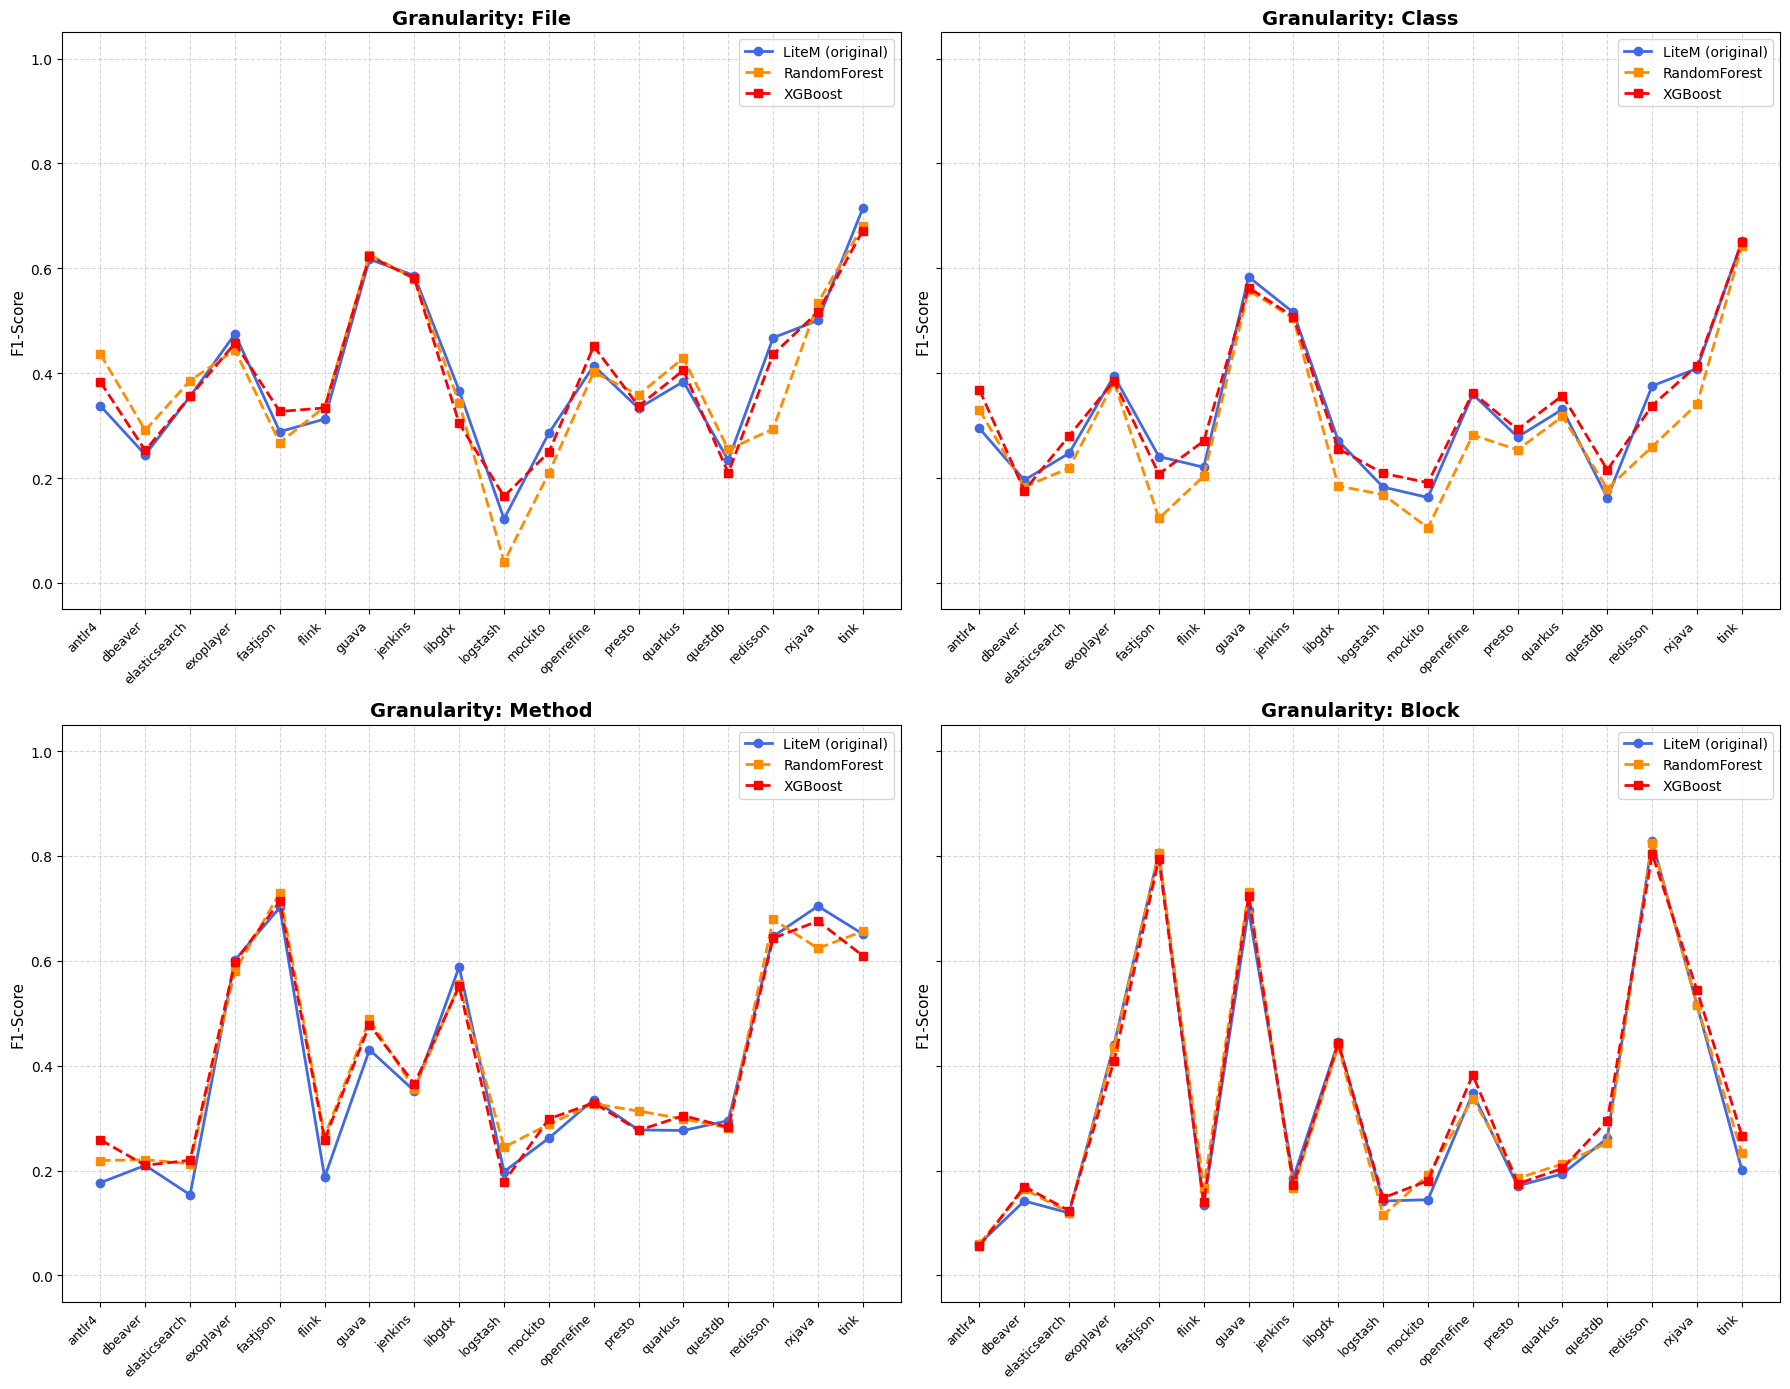

In [4]:
import matplotlib.pyplot as plt

# Set up a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharey=True)
axes = axes.flatten()

# Get the list of granularities (assumes both models have the same keys)
granularities = list(model_results["LiteM (original)"].keys())

# Define styling for the models to distinguish them visually
model_styles = {
    "LiteM (original)": {"color": "royalblue", "marker": "o", "linestyle": "-"},
    "RandomForest": {"color": "darkorange", "marker": "s", "linestyle": "--"},
    "XGBoost": {"color": "red", "marker": "s", "linestyle": "--"}
}

# Loop through each granularity and its assigned subplot axis
for ax, granularity in zip(axes, granularities):
    
    # Plot each model's line for the current granularity
    for model_name, style in model_styles.items():
        # Safeguard in case a project or granularity is missing in one dictionary
        gran_data = model_results[model_name].get(granularity, {})
        
        projects = list(gran_data.keys())
        scores = list(gran_data.values())
        
        if projects: # Only plot if data exists
            ax.plot(
                projects, 
                scores, 
                label=model_name,
                marker=style["marker"], 
                color=style["color"], 
                linestyle=style["linestyle"],
                linewidth=2, 
                markersize=6
            )
    
    # Subplot styling
    ax.set_title(f"Granularity: {granularity.capitalize()}", fontsize=14, fontweight='bold')
    ax.set_ylabel("F1-Score", fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Set the X-ticks explicitly to match the project labels
    ax.set_xticks(range(len(projects)))
    ax.set_xticklabels(projects, rotation=45, ha='right', fontsize=9)
    
    # Add a legend to each individual subplot
    ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()